In [38]:
# === Έλεγχος dataset πριν από την εκτέλεση ===
import os

file_path = "/content/flights_2000.csv"

if not os.path.exists(file_path):
    from google.colab import files
    print("Το αρχείο flights_2000.csv δεν βρέθηκε.")
    print("Παρακαλώ ανεβάστε το αρχείο μέσω του κουμπιού:")
    files.upload()
else:
    print("Το αρχείο flights_2000.csv εντοπίστηκε επιτυχώς.")

Το αρχείο flights_2000.csv εντοπίστηκε επιτυχώς.


In [18]:
!apt-get install -qq openjdk-11-jdk > /dev/null

# Νέο link από mirror (Spark 3.5.0 με Hadoop 3)
!wget -q https://archive.apache.org/dist/spark/spark-3.5.0/spark-3.5.0-bin-hadoop3.tgz

# Αποσυμπίεση
!tar xf spark-3.5.0-bin-hadoop3.tgz

# Εγκατάσταση findspark
!pip install -q findspark

In [19]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.0-bin-hadoop3"
os.environ["PATH"] = f'{os.environ["SPARK_HOME"]}/bin:{os.environ["JAVA_HOME"]}/bin:' + os.environ["PATH"]

!ls /content/spark-3.5.0-bin-hadoop3

bin   data	jars	    LICENSE   NOTICE  R		 RELEASE  yarn
conf  examples	kubernetes  licenses  python  README.md  sbin


In [20]:
# Έλεγχος ότι η Java εγκαταστάθηκε σωστά
!java -version

# Έλεγχος ότι το Spark είναι διαθέσιμο και λειτουργεί
!ls /content/spark-3.5.0-bin-hadoop3

# Έλεγχος έκδοσης Spark
!${SPARK_HOME}/bin/spark-submit --version

openjdk version "11.0.28" 2025-07-15
OpenJDK Runtime Environment (build 11.0.28+6-post-Ubuntu-1ubuntu122.04.1)
OpenJDK 64-Bit Server VM (build 11.0.28+6-post-Ubuntu-1ubuntu122.04.1, mixed mode, sharing)
bin   data	jars	    LICENSE   NOTICE  R		 RELEASE  yarn
conf  examples	kubernetes  licenses  python  README.md  sbin
Welcome to
      ____              __
     / __/__  ___ _____/ /__
    _\ \/ _ \/ _ `/ __/  '_/
   /___/ .__/\_,_/_/ /_/\_\   version 3.5.0
      /_/
                        
Using Scala version 2.12.18, OpenJDK 64-Bit Server VM, 11.0.28
Branch HEAD
Compiled by user ubuntu on 2023-09-09T01:53:20Z
Revision ce5ddad990373636e94071e7cef2f31021add07b
Url https://github.com/apache/spark
Type --help for more information.


In [21]:
import findspark
findspark.init()   # Ενεργοποιεί τη σύνδεση Python ↔ Spark

from pyspark.sql import SparkSession

# Δημιουργία ή εκκίνηση SparkSession
spark = SparkSession.builder \
    .appName("Flight Delay Analytics") \
    .config("spark.ui.showConsoleProgress", "true") \
    .getOrCreate()

print(" Spark ξεκίνησε επιτυχώς!")
print("Spark version:", spark.version)

 Spark ξεκίνησε επιτυχώς!
Spark version: 3.5.0


In [22]:
file_path = "/content/flights_2000.csv"

In [23]:
df_test = spark.read.csv(file_path, header=True, inferSchema=True)
df_test.show(5)

+----------+-------+------+--------------+------------+-------------------+---------+-------------------+---------+-------+---------+
|   FL_DATE|AIRLINE|FL_NUM|ORIGIN_AIRPORT|DEST_AIRPORT|          SCHED_DEP|DEP_DELAY|          SCHED_ARR|ARR_DELAY|DIST_KM|CANCELLED|
+----------+-------+------+--------------+------------+-------------------+---------+-------------------+---------+-------+---------+
|2025-10-09|     WN|   198|           BOS|         LAX|2025-10-09 18:40:00|      -10|2025-10-10 00:27:00|        1|   4254|        0|
|2025-10-22|     DL|  2388|           ATL|         IAD|2025-10-22 19:00:00|       -6|2025-10-22 20:26:00|      -11|    861|        0|
|2025-09-29|     DL|  9806|           DEN|         DFW|2025-09-29 08:55:00|       12|2025-09-29 10:34:00|       20|   1033|        0|
|2025-09-15|     AS|  4397|           DFW|         ORD|2025-09-15 09:20:00|     NULL|2025-09-15 11:19:00|     NULL|   1293|        1|
|2025-10-13|     UA|  8925|           IAD|         LAX|2025-10

In [28]:
# === Θέμα 1 — RDD API: Top-10 αεροδρόμια με μεγαλύτερη Μ.Ο. καθυστέρηση ===
import time, csv
from statistics import mean

sc = spark.sparkContext

# 1) Διαβάζουμε ως text RDD
rdd_raw   = sc.textFile(file_path)
header    = rdd_raw.first()
rdd_lines = rdd_raw.filter(lambda line: line != header)

# Parser με csv.reader ώστε να χειρίζεται σωστά κόμματα/εισαγωγικά
# Σχήμα στη δήλωση εργασίας:
# [0] FL_DATE, [1] AIRLINE, [2] FL_NUM, [3] ORIGIN_AIRPORT, [4] DEST_AIRPORT,
# [5] SCHED_DEP, [6] SCHED_ARR, [7] DEP_DELAY, [8] ARR_DELAY, [9] DIST_KM, [10] CANCELLED
def parse_partition(partition_iter):
    reader = csv.reader(partition_iter)
    for parts in reader:
        try:
            cancelled = parts[10]
            dep_delay = parts[7]
            if cancelled == "0" and dep_delay not in ("", "NA", "null", None):
                origin = parts[3]
                delay  = float(dep_delay)
                # 2) map(): (origin_airport, delay_minutes) -> εδώ κρατάμε (delay,1) για μέσο όρο
                yield (origin, (delay, 1))
        except Exception:
            continue

def trimmed_mean(xs):
    xs = sorted(xs)
    if len(xs) <= 2:  # fallback
        return mean(xs)
    return mean(xs[1:-1])  # drop min & max

def run_once():
    t_total_start = time.perf_counter()

    # 3) Μέσος όρος ανά αεροδρόμιο με reduceByKey (άθροισμα, πλήθος → average)
    pairs    = rdd_lines.mapPartitions(parse_partition)              # (origin, (delay,1))
    reduced  = pairs.reduceByKey(lambda a,b: (a[0]+b[0], a[1]+b[1])) # (origin, (sum, count))
    averages = reduced.mapValues(lambda s: s[0]/s[1])                # (origin, avg_delay)

    # 4) Top-10 με μεγαλύτερη μέση καθυστέρηση (descending)
    t_action_start = time.perf_counter()
    top10 = averages.takeOrdered(10, key=lambda kv: -kv[1])          # ACTION
    t_action_end   = time.perf_counter()

    t_total_end = t_action_end  # το αποτέλεσμα παρήχθη

    total_time  = t_total_end  - t_total_start
    action_time = t_action_end - t_action_start
    return top10, total_time, action_time

# 5) Εκτέλεση 5 φορές
runs = [run_once() for _ in range(5)]
top10_last   = runs[-1][0]                    # sample output για παράδοση
total_times  = [r[1] for r in runs]
action_times = [r[2] for r in runs]

# 5a) Drop max/min και 5b) μέσος των 3 ενδιάμεσων
avg_total_trim  = trimmed_mean(total_times)
avg_action_trim = trimmed_mean(action_times)

# --- Εκτύπωση αποτελεσμάτων ---
print("=== RDD: Top-10 μέση καθυστέρηση ανά αεροδρόμιο (λεπτά) ===")
for origin, avg_d in top10_last:
    print(f"{origin}: {avg_d:.2f}")

print("\n-- Χρόνοι (δευτ.) --")
print("Συνολικός χρόνος (5 runs):", [round(x,4) for x in total_times])
print("Πρώτο action (5 runs)    :", [round(x,4) for x in action_times])
print("Μ.Ο. (trimmed) συνολικός :", round(avg_total_trim, 4))
print("Μ.Ο. (trimmed) action    :", round(avg_action_trim, 4))

=== RDD: Top-10 μέση καθυστέρηση ανά αεροδρόμιο (λεπτά) ===

-- Χρόνοι (δευτ.) --
Συνολικός χρόνος (5 runs): [0.7324, 0.5906, 0.5432, 0.505, 0.5114]
Πρώτο action (5 runs)    : [0.7155, 0.559, 0.5156, 0.4697, 0.496]
Μ.Ο. (trimmed) συνολικός : 0.5484
Μ.Ο. (trimmed) action    : 0.5235


In [31]:
# === Θέμα 2 — Spark DataFrame API ===
# Προϋπόθεση: spark session ενεργό και file_path = "/content/flights_2000.csv"

import time, shutil, os
from statistics import mean
from pyspark.sql.functions import col, avg

# 1) Διαβάστε ως DataFrame
df = spark.read.csv(file_path, header=True, inferSchema=True)

# 2) Εμφάνιση σχήματος
df.printSchema()

# 3) Φιλτράρισμα: μόνο CANCELLED=0 και έγκυρο DEP_DELAY (cast σε double)
df_clean = df.filter(col("CANCELLED") == 0) \
             .withColumn("DEP_DELAY_D", col("DEP_DELAY").cast("double")) \
             .na.drop(subset=["DEP_DELAY_D"])

def trimmed_mean(xs):
    xs = sorted(xs)
    if len(xs) <= 2:
        return mean(xs)
    return mean(xs[1:-1])  # drop min & max

def run_df_once():
    t_total_start  = time.perf_counter()

    # 3a) Μ.Ο. καθυστέρησης ανά διαδρομή (origin-dest)
    result = df_clean.groupBy("ORIGIN_AIRPORT", "DEST_AIRPORT") \
                     .agg(avg("DEP_DELAY_D").alias("avg_delay")) \
                     .orderBy(col("avg_delay").desc())

    # 3b) Top-10 routes (descending) — ACTION
    t_action_start = time.perf_counter()
    top10_rows = result.limit(10).collect()
    t_action_end   = time.perf_counter()

    t_total_end = t_action_end
    return top10_rows, (t_total_end - t_total_start), (t_action_end - t_action_start)

# 5) Εκτέλεση 5 φορές
runs = [run_df_once() for _ in range(5)]
top10_last    = runs[-1][0]     # sample output
total_times   = [r[1] for r in runs]
action_times  = [r[2] for r in runs]

avg_total_trim  = trimmed_mean(total_times)
avg_action_trim = trimmed_mean(action_times)

# 4) Αποθήκευση αποτελέσματος σε CSV (γράφουμε το τελικό top-10)
out_dir = "/content/out/top10_routes"
if os.path.exists(out_dir):
    shutil.rmtree(out_dir)

# Ξαναφτιάχνουμε το result για write.csv ώστε να είναι DataFrame (όχι λίστα)
result_final = df_clean.groupBy("ORIGIN_AIRPORT", "DEST_AIRPORT") \
                       .agg(avg("DEP_DELAY_D").alias("avg_delay")) \
                       .orderBy(col("avg_delay").desc()) \
                       .limit(10)

result_final.write.mode("overwrite").csv(out_dir, header=True)

# --- Εκτυπώσεις για παράδοση ---
print("\n=== DataFrame: Top-10 routes με μεγαλύτερη μέση καθυστέρηση (DEP_DELAY) ===")
print(f"{'ROUTE (ORIGIN-DEST)':<25}  {'avg_delay (min)':>15}")
print("-"*45)
for r in top10_last:
    print(f"{r['ORIGIN_AIRPORT']}-{r['DEST_AIRPORT']:<17}  {r['avg_delay']:>15.2f}")

print("\n-- Χρόνοι (δευτ.) --")
print("Συνολικοί 5 runs     :", [round(x,4) for x in total_times])
print("Πρώτου action 5 runs :", [round(x,4) for x in action_times])
print("Μ.Ο. (trimmed) total :", round(avg_total_trim, 4))
print("Μ.Ο. (trimmed) action:", round(avg_action_trim, 4))

print(f"\nCSV saved to: {out_dir}")

root
 |-- FL_DATE: date (nullable = true)
 |-- AIRLINE: string (nullable = true)
 |-- FL_NUM: integer (nullable = true)
 |-- ORIGIN_AIRPORT: string (nullable = true)
 |-- DEST_AIRPORT: string (nullable = true)
 |-- SCHED_DEP: timestamp (nullable = true)
 |-- DEP_DELAY: integer (nullable = true)
 |-- SCHED_ARR: timestamp (nullable = true)
 |-- ARR_DELAY: integer (nullable = true)
 |-- DIST_KM: integer (nullable = true)
 |-- CANCELLED: integer (nullable = true)


=== DataFrame: Top-10 routes με μεγαλύτερη μέση καθυστέρηση (DEP_DELAY) ===
ROUTE (ORIGIN-DEST)        avg_delay (min)
---------------------------------------------
DFW-JFK                          23.30
JFK-LAS                          22.80
MIA-JFK                          20.50
MCO-ORD                          19.82
MCO-LAX                          19.14
BOS-SEA                          18.86
DFW-ATL                          18.62
BOS-PHX                          18.18
JFK-MIA                          18.00
DEN-SFO           

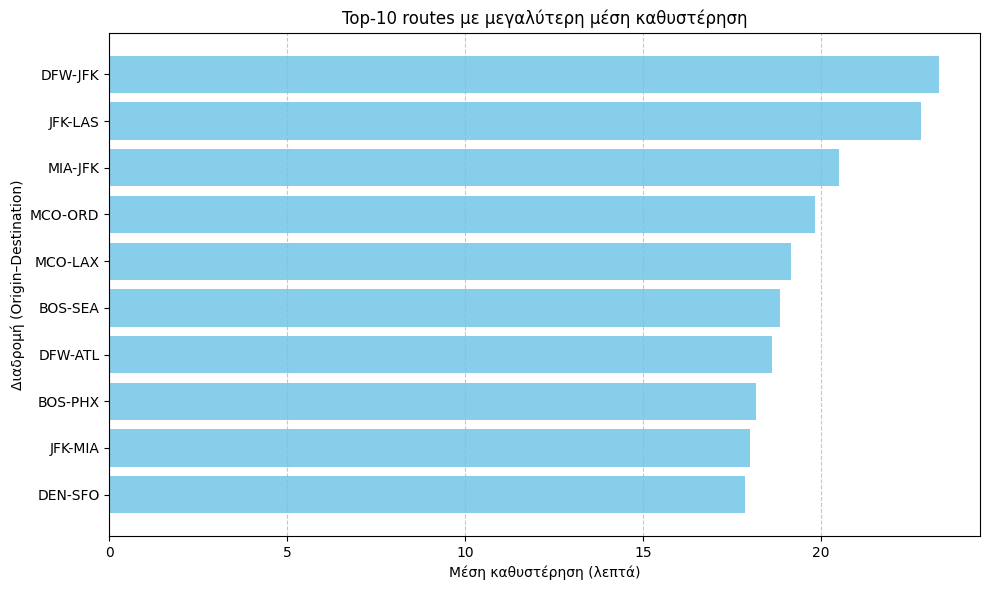

In [34]:
import matplotlib.pyplot as plt

# Μετατροπή του Spark DataFrame (top10_routes) σε Pandas DataFrame
pdf = result_final.toPandas()

# Δημιουργία οριζόντιου γραφήματος (barh)
plt.figure(figsize=(10,6))
plt.barh(pdf['ORIGIN_AIRPORT'] + '-' + pdf['DEST_AIRPORT'], pdf['avg_delay'], color='skyblue')
plt.xlabel('Μέση καθυστέρηση (λεπτά)')
plt.ylabel('Διαδρομή (Origin–Destination)')
plt.title('Top-10 routes με μεγαλύτερη μέση καθυστέρηση')
plt.gca().invert_yaxis()  # ώστε το μεγαλύτερο να είναι επάνω
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

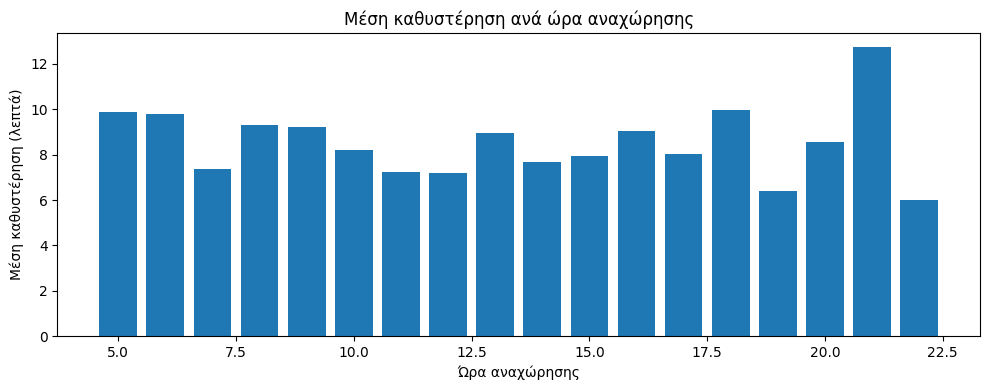

Saved plot -> /content/avg_delay_by_hour.png


In [35]:
# Average DEP_DELAY by departure HOUR (from SCHED_DEP)
from pyspark.sql.functions import date_format, col, avg
import matplotlib.pyplot as plt

# 1) Εξαγωγή ώρας (assignment hint έδινε substr, εδώ χρησιμοποιούμε ασφαλέστερα date_format)
df_hour = (df_clean
           .withColumn("HOUR", date_format(col("SCHED_DEP"), "HH").cast("int"))
           .groupBy("HOUR")
           .agg(avg("DEP_DELAY_D").alias("avg_delay"))
           .orderBy("HOUR"))

# 2) Σε Pandas
pdf_hour = df_hour.toPandas()

# 3) Γράφημα
plt.figure(figsize=(10,4))
plt.bar(pdf_hour["HOUR"], pdf_hour["avg_delay"])
plt.xlabel("Ώρα αναχώρησης")
plt.ylabel("Μέση καθυστέρηση (λεπτά)")
plt.title("Μέση καθυστέρηση ανά ώρα αναχώρησης")
plt.tight_layout()
plt.savefig("/content/avg_delay_by_hour.png", dpi=150)
plt.show()

print("Saved plot -> /content/avg_delay_by_hour.png")